# LOB Analysis: Stylized Facts and Predictive Patterns

**Chapter 3: Market Microstructure**

**Docker image**: `ml4t`

**Section Reference**: See Section 3.3 (Limit Order Book Analysis)

## Purpose

This notebook analyzes reconstructed order book data to demonstrate empirically-grounded
patterns with predictive power. These patterns motivate feature engineering in **Chapter 8**
and execution cost modeling in **Chapter 19**.

## Pipeline Position

```
nasdaq_itch_parser (01)
       ↓
order_book_reconstruction (02) → LOB snapshots → THIS NOTEBOOK (03)
       ↓                                              ↓
order_lifecycle_analysis (04)               Ch8: Feature Engineering
```

**Upstream**: LOB snapshots from `02_itch_lob_reconstruction` in
`output/ch03/nasdaq_itch/order_book/{SYMBOL}/`

See the **README.md** for the full notebook inventory and learning paths.

## Learning Objectives

After completing this notebook, you will be able to:

| Pattern | What You'll Learn | Chapter Connection |
|---------|-------------------|-------------------|
| **LOB reconstruction** | Verify spread validity as quality check | Section 3.3 |
| **Spread dynamics** | Intraday U-shape in spreads and volatility | Ch8: Time features |
| **Order flow imbalance** | Buying/selling pressure predicts returns | Ch8: OFI features |
| **Liquidity spectrum** | 100x+ variation across stocks | Ch19: Price impact |

## Key Insight

The patterns demonstrated here are well-documented "stylized facts" of market
microstructure. See Bouchaud et al. (2018) for a comprehensive treatment.

---

## Setup

In [1]:
"""LOB Analysis: Stylized Facts and Predictive Patterns — empirical patterns in reconstructed order book data."""

import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

In [2]:
# Production defaults — Papermill injects overrides for CI

In [3]:
# Visualization style - centralized in utils/style.py
import matplotlib.dates as mdates  # noqa: F401 - used in depth evolution
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.ticker import FuncFormatter  # noqa: F401

from utils.style import COLORS

# LOB-specific colors extending the ML4T palette
COLORS = {
    **COLORS,
    "bid": "#2E7D32",  # Green for bids
    "ask": "#C62828",  # Red for asks
}

In [4]:
# Configuration - Unified output directory structure
from data.equities.loader import load_nasdaq_itch
from utils.paths import get_output_dir

# All ITCH-related outputs under a single chapter directory
NASDAQ_ITCH_OUTPUT = get_output_dir(3, "nasdaq_itch")
OUTPUT_DIR = get_output_dir(3, "lob_analysis")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Input: LOB snapshots from notebook 02 (order book reconstruction)
ORDER_BOOK_DIR = NASDAQ_ITCH_OUTPUT / "order_book"

# Input: Pre-parsed ITCH messages from canonical data location
MESSAGES_DIR = load_nasdaq_itch(get_base_path=True)

# Output: Figures go with their source data in ORDER_BOOK_DIR/{symbol}/
# (no separate lob_analysis directory - keep outputs with their data)

### Discover Available Symbols

Scan the order book directory for symbols with reconstructed LOB data.

In [5]:
TRADING_DATE = "2020-01-30"


def discover_available_symbols(base_dir: Path) -> list[str]:
    """Find all symbols with reconstructed LOB data."""
    symbols = []
    if not base_dir.exists():
        return symbols
    for subdir in sorted(base_dir.iterdir()):
        if subdir.is_dir() and (subdir / "lob_snapshots.parquet").exists():
            symbols.append(subdir.name)
    return symbols


AVAILABLE_SYMBOLS = discover_available_symbols(ORDER_BOOK_DIR)

print(f"Data directory: {ORDER_BOOK_DIR}")
print(
    f"Available symbols: {AVAILABLE_SYMBOLS if AVAILABLE_SYMBOLS else 'None (run notebook 02 first)'}"
)
print("(Figures saved to each symbol's directory)")

Data directory: 03_market_microstructure/output/nasdaq_itch/order_book
Available symbols: ['AAPL', 'AAWW', 'AFMC', 'AGRX', 'AIRI', 'AMD', 'AUG', 'AVGR', 'BAC-A', 'BGR', 'BRN', 'CDMO', 'CIK', 'CMRE-E', 'DBO', 'DIA', 'DWX', 'ELAT', 'FPX', 'FUT', 'GHG', 'ISIG', 'ISR', 'ITRN', 'IWM', 'JOYY', 'LOAC', 'MITK', 'MSFT', 'NWPX', 'NWS', 'OVID', 'PBE', 'PMM', 'PRTY', 'PSCU', 'QQQ', 'RCON', 'RETA', 'RUBI', 'RYF', 'SBR', 'SH', 'SPY', 'TAP', 'TQQQ', 'UBP-K', 'VGI', 'WINS', 'XLK']
(Figures saved to each symbol's directory)


## 1. Load Reconstructed LOB Data

LOB snapshots were generated by `02_itch_lob_reconstruction.py` and saved to
`output/ch03/nasdaq_itch/order_book/{SYMBOL}/`. Each symbol has its own directory
containing snapshots and order-level data.

If data is missing, run notebook 02 first.

In [6]:
def load_lob_snapshots(symbol: str, base_dir: Path) -> pl.DataFrame | None:
    """Load LOB snapshots for a symbol from the order book directory."""
    symbol_dir = base_dir / symbol
    snapshot_file = symbol_dir / "lob_snapshots.parquet"

    if snapshot_file.exists():
        df = pl.read_parquet(snapshot_file)
        print(f"  {symbol}: {len(df):,} snapshots loaded")
        return df

    print(f"  {symbol}: Not found at {snapshot_file}")
    return None

In [7]:
# Load available LOB data (dynamically discovered)
print("Loading LOB snapshots from order_book_reconstruction output:")
lob_data = {}

for symbol in AVAILABLE_SYMBOLS:
    df = load_lob_snapshots(symbol, ORDER_BOOK_DIR)
    if df is not None:
        lob_data[symbol] = df

assert lob_data, (
    f"No LOB snapshots found at {ORDER_BOOK_DIR}.\n"
    "This notebook needs LOB data from the ITCH pipeline:\n"
    "  1. Download: uv run python data/equities/market/microstructure/nasdaq_itch_download.py\n"
    "  2. Parse:    Run 01_itch_parser.py\n"
    "  3. Reconstruct LOB: Run 02_itch_lob_reconstruction.py\n"
    f"  Expected output: {ORDER_BOOK_DIR}/{{SYMBOL}}/lob_snapshots.parquet"
)
print(f"\nLoaded {len(lob_data)} symbols for analysis.")

Loading LOB snapshots from order_book_reconstruction output:
  AAPL: 22,450 snapshots loaded
  AAWW: 5,325 snapshots loaded
  AFMC: 1,095 snapshots loaded
  AGRX: 5,115 snapshots loaded
  AIRI: 224 snapshots loaded
  AMD: 22,260 snapshots loaded
  AUG: 577 snapshots loaded
  AVGR: 1,191 snapshots loaded
  BAC-A: 72 snapshots loaded
  BGR: 1,103 snapshots loaded
  BRN: 24 snapshots loaded
  CDMO: 2,736 snapshots loaded
  CIK: 261 snapshots loaded
  CMRE-E: 47 snapshots loaded
  DBO: 7,996 snapshots loaded
  DIA: 22,319 snapshots loaded
  DWX: 3,220 snapshots loaded
  ELAT: 451 snapshots loaded
  FPX: 7,822 snapshots loaded
  FUT: 3,556 snapshots loaded
  GHG: 478 snapshots loaded
  ISIG: 75 snapshots loaded
  ISR: 611 snapshots loaded
  ITRN: 1,572 snapshots loaded
  IWM: 22,544 snapshots loaded
  JOYY: 58 snapshots loaded
  LOAC: 30 snapshots loaded
  MITK: 1,508 snapshots loaded
  MSFT: 22,298 snapshots loaded
  NWPX: 1,307 snapshots loaded
  NWS: 6,436 snapshots loaded
  OVID: 1,638 

## 2. Spread Dynamics: Intraday Patterns

The bid-ask spread exhibits a well-documented **U-shape** throughout the trading day:
- **Wide at open**: Uncertainty, overnight news digestion
- **Narrow midday**: Lower volatility, stable information flow
- **Wide at close**: Position squaring, end-of-day volatility

See Section 3.3 for discussion; Chapter 8 shows how to engineer time-of-day features.

In [8]:
def compute_spread_metrics(lob_df: pl.DataFrame) -> pl.DataFrame:
    """Compute spread-related metrics from LOB snapshots."""
    result = lob_df.clone()

    # Ensure spread exists
    if "spread" not in result.columns:
        if "best_ask" in result.columns and "best_bid" in result.columns:
            result = result.with_columns((pl.col("best_ask") - pl.col("best_bid")).alias("spread"))

    # Mid price if not present
    if "mid_price" not in result.columns and "best_ask" in result.columns:
        result = result.with_columns(
            ((pl.col("best_ask") + pl.col("best_bid")) / 2).alias("mid_price")
        )

    # Spread in basis points (only meaningful for positive spreads)
    if "spread" in result.columns and "mid_price" in result.columns:
        result = result.with_columns(
            (pl.col("spread") / pl.col("mid_price") * 10000).alias("spread_bps")
        )

    return result

In [9]:
# Select first available stock for spread dynamics analysis
SPREAD_SYMBOL = list(lob_data.keys())[0] if lob_data else None

spread_1m = None
mid_1m = None

if lob_data and SPREAD_SYMBOL:
    spread_df = compute_spread_metrics(lob_data[SPREAD_SYMBOL])

    # Filter to valid spreads only
    spread_df = spread_df.filter(pl.col("spread") > 0)

    if len(spread_df) > 10:
        # Convert timestamp to pandas for time-series operations
        spread_pd = spread_df.to_pandas()
        if "timestamp" in spread_pd.columns:
            # CRITICAL: Force datetime64[ns] - pandas .plot() fails with [us]
            spread_pd["timestamp"] = spread_pd["timestamp"].astype("datetime64[ns]")
            spread_pd = spread_pd.set_index("timestamp")

        # Resample to 1-minute for cleaner visualization
        if "spread_bps" in spread_pd.columns:
            spread_1m = spread_pd["spread_bps"].resample("1min").mean()
            mid_1m = spread_pd["mid_price"].resample("1min").last()
    else:
        print(f"Not enough valid spread data for {SPREAD_SYMBOL}")

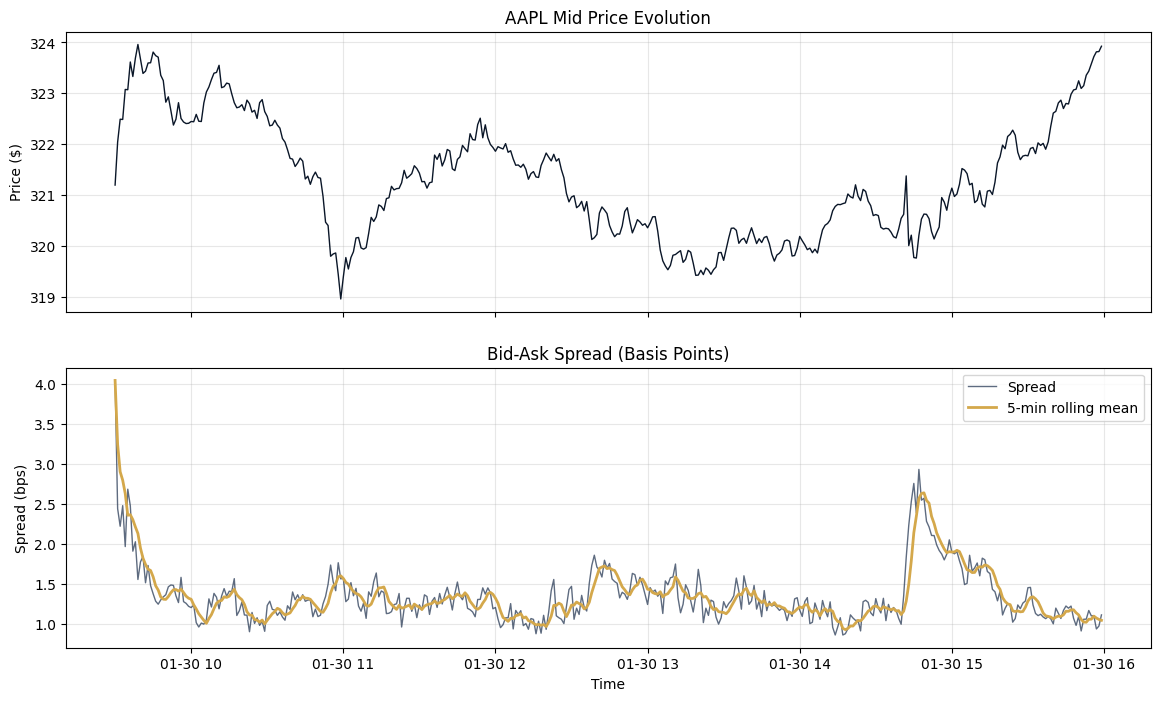

In [10]:
# Visualize spread dynamics — build panels
if spread_1m is not None and mid_1m is not None:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    # Panel 1: Mid price (use matplotlib directly for reliable datetime handling)
    mid_clean = mid_1m.dropna()
    axes[0].plot(mid_clean.index, mid_clean.values, color=COLORS["blue"], linewidth=1)
    axes[0].set_title(f"{SPREAD_SYMBOL} Mid Price Evolution")
    axes[0].set_ylabel("Price ($)")
    axes[0].grid(True, alpha=0.3)

    # Panel 2: Spread with rolling mean
    spread_clean = spread_1m.dropna()
    axes[1].plot(
        spread_clean.index,
        spread_clean.values,
        color=COLORS["slate"],
        linewidth=1,
        alpha=0.7,
        label="Spread",
    )

    # Rolling mean (5-minute window) shows trend without noise
    if len(spread_clean) > 5:
        rolling_mean = spread_clean.rolling(window=5, min_periods=1).mean()
        axes[1].plot(
            rolling_mean.index,
            rolling_mean.values,
            color=COLORS["amber"],
            linewidth=2,
            label="5-min rolling mean",
        )

    axes[1].set_title("Bid-Ask Spread (Basis Points)")
    axes[1].set_ylabel("Spread (bps)")
    axes[1].set_xlabel("Time")
    axes[1].legend(loc="upper right")
    axes[1].grid(True, alpha=0.3)

In [11]:
# Format and display spread dynamics figure
if spread_1m is not None and mid_1m is not None:
    import matplotlib.dates as mdates

    axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    fig.autofmt_xdate()

    plt.suptitle(
        f"Intraday Spread Dynamics - {SPREAD_SYMBOL} ({TRADING_DATE})",
        fontsize=12,
        fontweight="bold",
    )
    plt.show()

    print(f"\nSpread Statistics ({SPREAD_SYMBOL}):")
    print(f"  Mean: {spread_clean.mean():.2f} bps")
    print(f"  Median: {spread_clean.median():.2f} bps")

<Figure size 640x480 with 0 Axes>


Spread Statistics (AAPL):
  Mean: 1.35 bps
  Median: 1.28 bps


## 3. Top-of-Book Evolution

This visualization tracks the evolution of best bid, best ask, and mid price
across the trading session, with bid/ask point intensity encoding the
resting depth at the inside quote.

- **X-axis**: Time
- **Y-axis**: Price (\$)
- **Blue points**: Best bid, intensity = log(bid_size_0)
- **Red points**: Best ask, intensity = log(ask_size_0)
- **Black line**: Mid price evolution

The reconstruction from `02_itch_lob_reconstruction` emits inside-quote
snapshots (`best_bid`, `best_ask`, `bid_size_0`, `ask_size_0`); deeper
levels are out of scope for the Numba LOB path. For multi-level book
visualizations see `08_databento_lob_reconstruction` (Databento MBO).

In [12]:
def _resample_side_depth(pdf, price_col: str, size_col: str, freq: str) -> list[dict]:
    """Resample one side's depth at a single level into scatter records."""
    if price_col not in pdf.columns or size_col not in pdf.columns:
        return []
    resampled = (
        pdf[[price_col, size_col]].resample(freq).agg({price_col: "last", size_col: "sum"}).dropna()
    )
    return [
        {"timestamp": ts, "price": row[price_col], "depth": row[size_col]}
        for ts, row in resampled.iterrows()
        if row[size_col] > 0
    ]

### Build Depth Scatter Data
Resample order book levels to a fixed frequency for scatter visualization.

In [13]:
def build_depth_scatter_data(
    lob_df: pl.DataFrame, n_levels: int = 1, resample_freq: str = "1min"
) -> tuple:
    """Build scatter plot data for top-of-book / inside-quote visualization.

    Resamples to the specified frequency and extracts bid/ask prices and depths
    at each requested level. ``n_levels>1`` only returns rows where per-level
    price columns (``bid_price_{i}``, ``ask_price_{i}``) are present in
    ``lob_df``; on ITCH inside-quote frames levels >0 degrade silently to
    empty.

    Args:
        lob_df: LOB snapshot DataFrame with bid/ask price and size columns
        n_levels: Number of price levels to include (1 = top-of-book only)
        resample_freq: Resample frequency (e.g., "1min", "5min")

    Returns:
        Tuple of (mid_prices_df, bid_scatter_df, ask_scatter_df)
        Each scatter df has columns: [timestamp, price, depth, log_depth]
    """
    import pandas as pd

    # Convert to pandas for resampling
    pdf = lob_df.to_pandas()
    pdf["timestamp"] = pd.to_datetime(pdf["timestamp"])
    pdf = pdf.set_index("timestamp")

    # Schema compatibility: the ITCH Numba LOB path emits top-of-book
    # (best_bid/best_ask) rather than per-level price columns; alias them
    # to the level-0 names that the resampler expects.
    if "bid_price_0" not in pdf.columns and "best_bid" in pdf.columns:
        pdf["bid_price_0"] = pdf["best_bid"]
    if "ask_price_0" not in pdf.columns and "best_ask" in pdf.columns:
        pdf["ask_price_0"] = pdf["best_ask"]

    # Resample mid prices
    if "mid_price" not in pdf.columns:
        pdf["mid_price"] = (pdf["best_bid"] + pdf["best_ask"]) / 2

    mid_prices = pdf["mid_price"].resample(resample_freq).last().dropna()

    # Build bid/ask scatter data across all levels
    bid_records, ask_records = [], []
    for level in range(n_levels):
        bid_records.extend(
            _resample_side_depth(pdf, f"bid_price_{level}", f"bid_size_{level}", resample_freq)
        )
        ask_records.extend(
            _resample_side_depth(pdf, f"ask_price_{level}", f"ask_size_{level}", resample_freq)
        )

    bid_df = pd.DataFrame(bid_records)
    ask_df = pd.DataFrame(ask_records)

    # Add log depth for color scaling
    if not bid_df.empty:
        bid_df["log_depth"] = np.log1p(bid_df["depth"])
    if not ask_df.empty:
        ask_df["log_depth"] = np.log1p(ask_df["depth"])

    return mid_prices, bid_df, ask_df

In [14]:
# Build depth evolution scatter data
import matplotlib.patches as mpatches

DEPTH_SYMBOL = list(lob_data.keys())[0] if lob_data else None
mid_prices = None
bid_scatter = None
ask_scatter = None

if lob_data and DEPTH_SYMBOL:
    depth_lob = lob_data[DEPTH_SYMBOL]

    # Build scatter data — the ITCH LOB path tracks the inside quote only,
    # so a single level is what's available. Resample to 1-minute for
    # cleaner visualization.
    mid_prices, bid_scatter, ask_scatter = build_depth_scatter_data(
        depth_lob, n_levels=1, resample_freq="1min"
    )

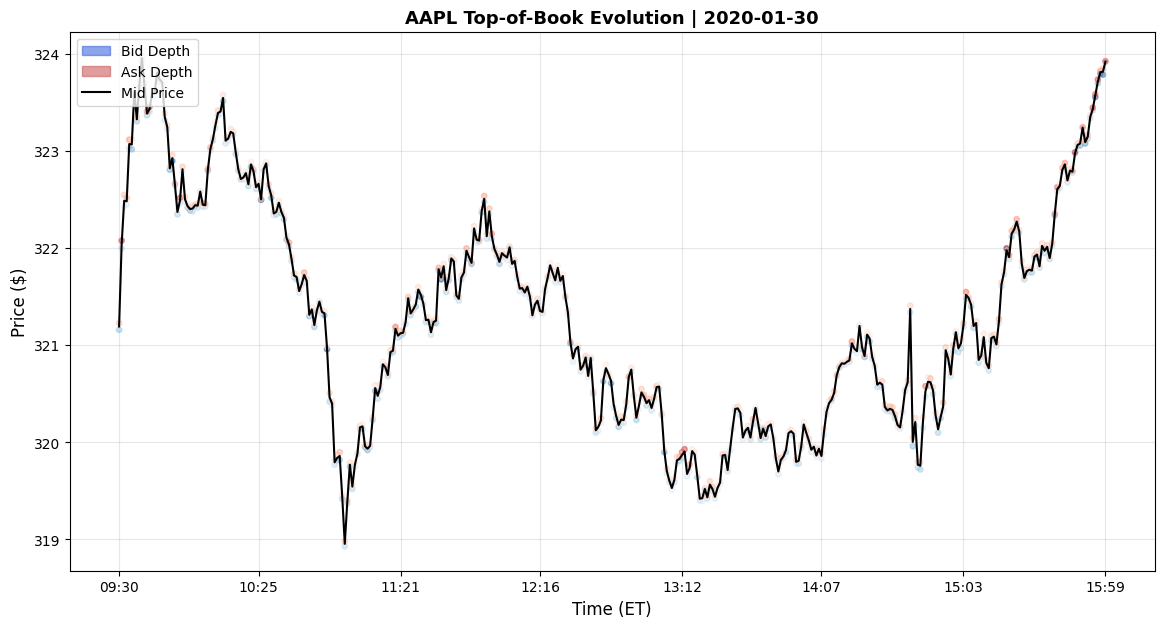

In [15]:
# Visualize depth evolution (scatter plot style) - SINGLE cell so the inline
# backend cannot flush an intermediate render with raw-nanosecond x-ticks
# (feedback_split_cell_figure_bug).
if (
    mid_prices is not None
    and len(mid_prices) > 10
    and bid_scatter is not None
    and not bid_scatter.empty
):
    fig, ax = plt.subplots(figsize=(14, 7))

    # Convert timestamps to numeric for matplotlib
    # CRITICAL: Ensure consistent nanosecond precision. The mid_prices index from
    # resampling retains the original Polars microsecond unit (datetime64[us]),
    # while DataFrames built from dicts default to nanoseconds (datetime64[ns]).
    # Without explicit conversion, these differ by 1000x causing axis misalignment.
    mid_ts_numeric = mid_prices.index.astype("datetime64[ns]").astype(np.int64)
    bid_ts_numeric = bid_scatter["timestamp"].astype("datetime64[ns]").astype(np.int64)
    ask_ts_numeric = ask_scatter["timestamp"].astype("datetime64[ns]").astype(np.int64)

    # Plot bid depth (blue) - below mid price
    ax.scatter(
        bid_ts_numeric,
        bid_scatter["price"],
        c=bid_scatter["log_depth"],
        cmap="Blues",
        alpha=0.4,
        s=15,
        label="Bid",
    )

    # Plot ask depth (red) - above mid price
    ax.scatter(
        ask_ts_numeric,
        ask_scatter["price"],
        c=ask_scatter["log_depth"],
        cmap="Reds",
        alpha=0.4,
        s=15,
        label="Ask",
    )

    # Plot mid price as black line
    ax.plot(mid_ts_numeric, mid_prices.values, color="black", linewidth=1.5, label="Mid Price")

    # Format x-axis with clock-time labels (avoid raw nanosecond ticks)
    n_ticks = 8
    tick_indices = np.linspace(0, len(mid_prices) - 1, n_ticks, dtype=int)
    tick_positions = mid_ts_numeric[tick_indices]
    tick_labels = [mid_prices.index[i].strftime("%H:%M") for i in tick_indices]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels)

    ax.set_ylabel("Price ($)", fontsize=12)
    ax.set_xlabel("Time (ET)", fontsize=12)

    # Add legend with colored patches
    blue_patch = mpatches.Patch(color="royalblue", alpha=0.6, label="Bid Depth")
    red_patch = mpatches.Patch(color="indianred", alpha=0.6, label="Ask Depth")
    black_line = plt.Line2D([0], [0], color="black", linewidth=1.5, label="Mid Price")
    ax.legend(handles=[blue_patch, red_patch, black_line], loc="upper left")

    ax.set_title(
        f"{DEPTH_SYMBOL} Top-of-Book Evolution | {TRADING_DATE}",
        fontsize=13,
        fontweight="bold",
    )
    ax.grid(True, alpha=0.3)

    plt.show()
else:
    print("WARNING: Insufficient LOB data for top-of-book evolution visualization")

In [16]:
# Summary statistics
if (
    mid_prices is not None
    and len(mid_prices) > 10
    and bid_scatter is not None
    and not bid_scatter.empty
):
    print(f"\nTop-of-Book Evolution Summary ({DEPTH_SYMBOL}):")
    print(f"  Time range: {mid_prices.index.min()} to {mid_prices.index.max()}")
    print(f"  Price range: ${mid_prices.min():.2f} to ${mid_prices.max():.2f}")
    print(f"  Bid points: {len(bid_scatter):,}")
    print(f"  Ask points: {len(ask_scatter):,}")
    if not bid_scatter.empty:
        print(f"  Avg bid depth: {bid_scatter['depth'].mean():,.0f} shares")
    if not ask_scatter.empty:
        print(f"  Avg ask depth: {ask_scatter['depth'].mean():,.0f} shares")


Top-of-Book Evolution Summary (AAPL):
  Time range: 2020-01-30 09:30:00 to 2020-01-30 15:59:00
  Price range: $318.96 to $323.96
  Bid points: 390
  Ask points: 390
  Avg bid depth: 9,090 shares
  Avg ask depth: 10,187 shares


## 4. Order Flow Imbalance (OFI)

**Order Flow Imbalance** measures the net pressure from incoming orders, cancellations,
and executions. Unlike static depth (a snapshot), OFI captures *dynamics*—who is
actively adding vs removing liquidity.

**Formula** (per time bucket):
```
OFI = (Bid Additions - Bid Removals) - (Ask Additions - Ask Removals)
```

- OFI > 0: Net buying pressure
- OFI < 0: Net selling pressure

### 4.1 Build Order Registry

First, we build a registry of all orders from Add messages (A/F) to track
which orders belong to which side.

In [17]:
def load_order_registry(messages_dir: Path, symbol: str) -> pl.DataFrame:
    """Build order registry: order_reference_number → (side, shares, price, timestamp)."""
    orders = []
    for msg_type in ["A", "F"]:
        path = messages_dir / msg_type
        if path.exists():
            df = (
                pl.scan_parquet(path / "*.parquet")
                .filter(pl.col("stock") == symbol)
                .select(
                    ["order_reference_number", "buy_sell_indicator", "shares", "price", "timestamp"]
                )
                .collect()
            )
            if len(df) > 0:
                orders.append(df)
    if not orders:
        return pl.DataFrame()
    return pl.concat(orders).rename({"buy_sell_indicator": "side"})

### 4.2 Load Order Removals

Track when orders are removed: deletions (D), cancellations (X), and executions (E).

In [18]:
def load_order_removals(messages_dir: Path, order_refs: set) -> pl.DataFrame:
    """Load cancel/delete/execute messages for orders in our registry."""
    removals = []

    # Delete messages (D) - full order deletion
    d_path = messages_dir / "D"
    if d_path.exists():
        d_df = (
            pl.scan_parquet(d_path / "*.parquet")
            .filter(pl.col("order_reference_number").is_in(order_refs))
            .select(["timestamp", "order_reference_number"])
            .collect()
        )
        if len(d_df) > 0:
            d_df = d_df.with_columns(pl.lit("delete").alias("event_type"))
            removals.append(d_df)

    # Cancel messages (X) - partial cancellation
    x_path = messages_dir / "X"
    if x_path.exists():
        x_df = (
            pl.scan_parquet(x_path / "*.parquet")
            .filter(pl.col("order_reference_number").is_in(order_refs))
            .select(["timestamp", "order_reference_number", "cancelled_shares"])
            .collect()
        )
        if len(x_df) > 0:
            x_df = x_df.rename({"cancelled_shares": "shares_removed"})
            x_df = x_df.with_columns(pl.lit("cancel").alias("event_type"))
            removals.append(x_df)

    # Execute messages (E) - shares executed
    e_path = messages_dir / "E"
    if e_path.exists():
        e_df = (
            pl.scan_parquet(e_path / "*.parquet")
            .filter(pl.col("order_reference_number").is_in(order_refs))
            .select(["timestamp", "order_reference_number", "executed_shares"])
            .collect()
        )
        if len(e_df) > 0:
            e_df = e_df.rename({"executed_shares": "shares_removed"})
            e_df = e_df.with_columns(pl.lit("execute").alias("event_type"))
            removals.append(e_df)

    if not removals:
        return pl.DataFrame()
    return pl.concat(removals, how="diagonal")

### 4.3 Compute OFI

Aggregate additions and removals by time bucket, then compute the imbalance.

In [19]:
def _pivot_by_side(
    df: pl.DataFrame, freq: str, value_col: str, bid_name: str, ask_name: str
) -> pl.DataFrame:
    """Aggregate a DataFrame by time bucket and side, then pivot to wide format."""
    agg = (
        df.with_columns(pl.col("timestamp").dt.truncate(freq).alias("bucket"))
        .group_by(["bucket", "side"])
        .agg(pl.col(value_col).sum().alias(value_col))
    )
    pivot = agg.pivot(on="side", index="bucket", values=value_col).fill_null(0)
    if "B" in pivot.columns:
        pivot = pivot.rename({"B": bid_name})
    if "S" in pivot.columns:
        pivot = pivot.rename({"S": ask_name})
    return pivot

### Enrich Removals with Registry Data
Join order removals with the registry to recover side and share count for each removal event.

In [20]:
def _enrich_removals(removals: pl.DataFrame, registry: pl.DataFrame) -> pl.DataFrame:
    """Join removals with registry to get side and shares; fill missing shares_removed."""
    removals = removals.join(
        registry.select(["order_reference_number", "side", "shares"]),
        on="order_reference_number",
        how="left",
    )
    # Use shares from registry for deletes (full removal)
    if "shares_removed" not in removals.columns:
        removals = removals.with_columns(pl.col("shares").alias("shares_removed"))
    else:
        removals = removals.with_columns(
            pl.coalesce("shares_removed", "shares").alias("shares_removed")
        )
    return removals

### Compute Order Flow Imbalance
Aggregate order book changes into a directional imbalance measure at a given frequency.

In [21]:
def compute_ofi(messages_dir: Path, symbol: str, freq: str = "1m") -> pl.DataFrame:
    """Compute Order Flow Imbalance from raw ITCH messages."""
    # Build order registry
    registry = load_order_registry(messages_dir, symbol)
    if registry.is_empty():
        return pl.DataFrame()

    print(f"  {symbol}: {len(registry):,} orders")

    # Load removals and join with registry to get sides
    removals = load_order_removals(messages_dir, set(registry["order_reference_number"].to_list()))

    if not removals.is_empty():
        removals = _enrich_removals(removals, registry)
        print(f"  {symbol}: {len(removals):,} removals")

    # Aggregate additions and removals by time bucket
    add_pivot = _pivot_by_side(registry, freq, "shares", "bid_adds", "ask_adds")
    rem_pivot = (
        _pivot_by_side(removals, freq, "shares_removed", "bid_removes", "ask_removes")
        if not removals.is_empty()
        else pl.DataFrame({"bucket": []})
    )

    # Join and compute OFI
    ofi_df = add_pivot.join(rem_pivot, on="bucket", how="outer").fill_null(0)

    for col in ["bid_adds", "ask_adds", "bid_removes", "ask_removes"]:
        if col not in ofi_df.columns:
            ofi_df = ofi_df.with_columns(pl.lit(0).alias(col))

    # CRITICAL: Cast to Int64 before subtraction to avoid UInt32 underflow
    # (e.g., 100 - 200 as UInt32 = 4,294,967,196 instead of -100)
    ofi_df = ofi_df.with_columns(
        (
            (pl.col("bid_adds").cast(pl.Int64) - pl.col("bid_removes").cast(pl.Int64))
            - (pl.col("ask_adds").cast(pl.Int64) - pl.col("ask_removes").cast(pl.Int64))
        ).alias("ofi")
    ).sort("bucket")

    return ofi_df

### 4.4 OFI vs Returns Analysis

Join OFI with price data to measure predictive power.

In [22]:
# Initialize OFI analysis variables
OFI_SYMBOL = list(lob_data.keys())[0] if lob_data else None
ofi_arr = None
ret_arr = None
corr_raw = None
corr_log = None

In [23]:
# Compute OFI and align with price data
if MESSAGES_DIR.exists() and OFI_SYMBOL:
    print(f"Computing OFI for {OFI_SYMBOL}...")
    ofi_df = compute_ofi(MESSAGES_DIR, OFI_SYMBOL, freq="1m")

    if not ofi_df.is_empty() and OFI_SYMBOL in lob_data:
        lob_df = lob_data[OFI_SYMBOL]

        if "mid_price" in lob_df.columns:
            # Get price buckets
            prices = (
                lob_df.with_columns(pl.col("timestamp").dt.truncate("1m").alias("bucket"))
                .group_by("bucket")
                .agg(pl.col("mid_price").last())
            )

            # Align datetime units and join
            ofi_df = ofi_df.with_columns(pl.col("bucket").dt.cast_time_unit("us"))
            prices = prices.with_columns(pl.col("bucket").dt.cast_time_unit("us"))
            ofi_prices = ofi_df.join(prices, on="bucket", how="inner")

            # Compute next-period returns
            ofi_prices = ofi_prices.sort("bucket").with_columns(
                (pl.col("mid_price").pct_change().shift(-1) * 10000).alias("next_return_bps")
            )

            # Filter valid observations
            valid = ofi_prices.filter(
                pl.col("ofi").is_not_null() & pl.col("next_return_bps").is_finite()
            )

            if len(valid) >= 5:
                ofi_arr = valid["ofi"].to_numpy()
                ret_arr = valid["next_return_bps"].to_numpy()

                # Signed log transform: sign(x) * log(1 + |x|)
                ofi_log = np.sign(ofi_arr) * np.log1p(np.abs(ofi_arr))

                corr_raw = np.corrcoef(ofi_arr, ret_arr)[0, 1]
                corr_log = np.corrcoef(ofi_log, ret_arr)[0, 1]
            else:
                print(f"WARNING: Only {len(valid)} valid observations - need more LOB data")
else:
    print("WARNING: No ITCH messages found. Run notebook 01 first.")

Computing OFI for AAPL...


  AAPL: 907,157 orders


  AAPL: 927,624 removals


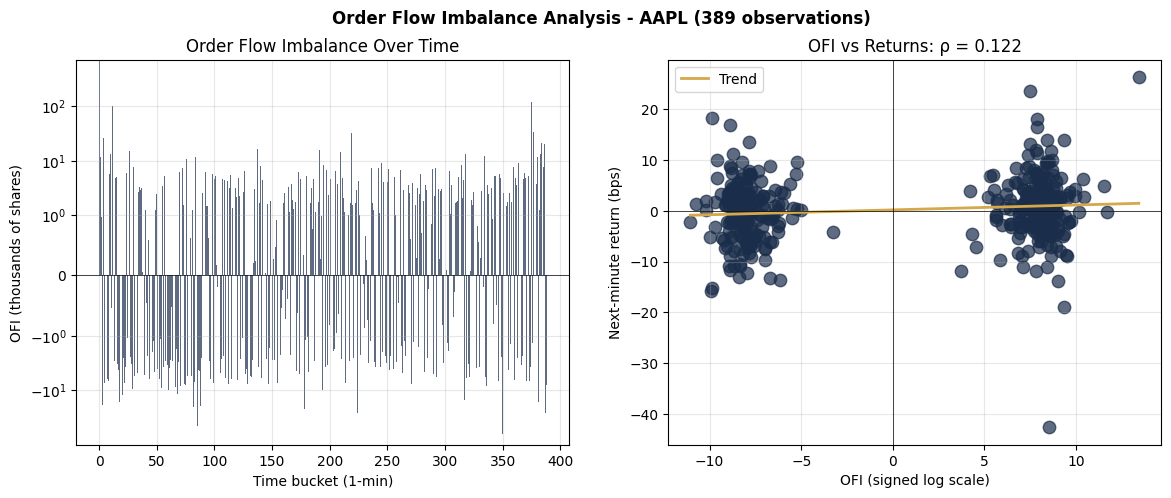


OFI Analysis (AAPL):
  Observations: 389
  Correlation (raw):  0.2147
  Correlation (log):  0.1217
  OFI range: -62,736 to 674,036 shares


In [24]:
# Visualize OFI vs returns
if ofi_arr is not None and ret_arr is not None:
    ofi_log = np.sign(ofi_arr) * np.log1p(np.abs(ofi_arr))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Panel 1: OFI time series (raw values, symlog scale)
    ofi_scaled = ofi_arr / 1000  # Scale to thousands for display
    axes[0].bar(range(len(ofi_arr)), ofi_scaled, color=COLORS["slate"], alpha=0.7)
    axes[0].axhline(0, color="black", lw=0.5)
    axes[0].set_xlabel("Time bucket (1-min)")
    axes[0].set_ylabel("OFI (thousands of shares)")
    axes[0].set_title("Order Flow Imbalance Over Time")
    axes[0].set_yscale("symlog", linthresh=1)  # Log scale for signed data
    axes[0].grid(True, alpha=0.3)

    # Panel 2: Scatter plot using log-transformed OFI
    axes[1].scatter(ofi_log, ret_arr, alpha=0.7, s=80, color=COLORS["slate"])

    # Trend line on log-transformed data
    z = np.polyfit(ofi_log, ret_arr, 1)
    x_line = np.linspace(ofi_log.min(), ofi_log.max(), 100)
    axes[1].plot(x_line, np.polyval(z, x_line), color=COLORS["amber"], lw=2, label="Trend")

    axes[1].axhline(0, color="black", lw=0.5)
    axes[1].axvline(0, color="black", lw=0.5)
    axes[1].set_xlabel("OFI (signed log scale)")
    axes[1].set_ylabel("Next-minute return (bps)")
    axes[1].set_title(f"OFI vs Returns: ρ = {corr_log:.3f}")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(
        f"Order Flow Imbalance Analysis - {OFI_SYMBOL} ({len(ofi_arr)} observations)",
        fontsize=12,
        fontweight="bold",
    )
    plt.show()

    print(f"\nOFI Analysis ({OFI_SYMBOL}):")
    print(f"  Observations: {len(ofi_arr)}")
    print(f"  Correlation (raw):  {corr_raw:.4f}")
    print(f"  Correlation (log):  {corr_log:.4f}")
    print(f"  OFI range: {ofi_arr.min():,.0f} to {ofi_arr.max():,.0f} shares")

### Compute Book Imbalance

Measure the ratio of bid-to-ask depth at the best level for predictability analysis.

In [25]:
def compute_book_imbalance(lob_df: pl.DataFrame) -> pl.DataFrame:
    """
    Compute order book imbalance from LOB snapshots.

    Imbalance at best level: (bid_size_0 - ask_size_0) / (bid_size_0 + ask_size_0)

    Note: We add +1 to the denominator to avoid division by zero when both
    sides are empty. This creates a slight bias toward zero for small values,
    which is acceptable for analysis purposes.
    """
    bid_col = "bid_size_0" if "bid_size_0" in lob_df.columns else None
    ask_col = "ask_size_0" if "ask_size_0" in lob_df.columns else None

    if bid_col is None or ask_col is None:
        return lob_df

    result = lob_df.clone()

    # Ensure spread column exists for downstream filtering
    if "spread" not in result.columns:
        if "best_ask" in result.columns and "best_bid" in result.columns:
            result = result.with_columns((pl.col("best_ask") - pl.col("best_bid")).alias("spread"))

    # Ensure mid_price exists
    if "mid_price" not in result.columns:
        if "best_ask" in result.columns and "best_bid" in result.columns:
            result = result.with_columns(
                ((pl.col("best_ask") + pl.col("best_bid")) / 2).alias("mid_price")
            )

    # Compute imbalance (add 1 to denominator to avoid div-by-zero)
    result = result.with_columns(
        ((pl.col(bid_col) - pl.col(ask_col)) / (pl.col(bid_col) + pl.col(ask_col) + 1)).alias(
            "book_imbalance"
        )
    )

    # Compute future returns for predictability analysis
    if "mid_price" in result.columns:
        result = result.with_columns(
            (pl.col("mid_price").pct_change().shift(-1) * 10000).alias("future_return_bps")
        )

    return result

## 5. Multi-Stock OFI Analysis: Correlation with Returns

Order Flow Imbalance (OFI) measures buying vs selling pressure over time:
OFI = (Bid Adds - Bid Removes) - (Ask Adds - Ask Removes)

Positive OFI → net buying pressure (more bids added/asks removed)
Negative OFI → net selling pressure (more asks added/bids removed)

This section examines OFI's predictive power across 50 stocks stratified by activity.

**Key finding**: OFI shows **weak, noisy correlation** with subsequent returns when
used naively. Correlations range from -0.3 to +0.5 with high variance.

**Implication**: Raw OFI isn't directly tradeable. Chapter 6 shows how **conditional
signals**—extreme OFI events plus spread dynamics—extract the actual edge.

To regenerate with different stocks:
```bash
ITCH_SYMBOL=XYZ uv run python 02_itch_lob_reconstruction.py
```

### Compute Per-Stock OFI Correlation

Measure OFI-to-return correlation for a single stock using 1-minute buckets.

In [26]:
def compute_ofi_correlation(lob_df: pl.DataFrame, symbol: str) -> dict | None:
    """Compute OFI → return correlation for a single stock.

    Uses pre-computed OFI from LOB snapshots (generated in notebook 02).
    Aggregates to 1-minute buckets for correlation with next-minute returns.

    Args:
        lob_df: LOB snapshot DataFrame with ofi, mid_price columns
        symbol: Stock symbol (for reporting)

    Returns:
        Dictionary with symbol, bucket_count, correlation, or None if insufficient data
    """
    # Check if OFI column exists (generated by reconstruct_lob_with_ofi)
    if "ofi" not in lob_df.columns:
        print(f"  {symbol}: No OFI column - rerun notebook 02 for this symbol")
        return None

    # Aggregate to 1-minute buckets
    df = (
        lob_df.with_columns(pl.col("timestamp").dt.truncate("1m").alias("bucket"))
        .group_by("bucket")
        .agg(
            pl.col("ofi").sum().alias("ofi_1m"),
            pl.col("mid_price").last().alias("mid_price"),
        )
        .sort("bucket")
    )

    # Compute next-minute returns
    df = df.with_columns(
        (pl.col("mid_price").pct_change().shift(-1) * 10000).alias("next_return_bps")
    )

    # Filter to valid observations
    valid = df.filter(pl.col("ofi_1m").is_not_null() & pl.col("next_return_bps").is_finite())

    if len(valid) < 50:
        return None

    ofi_arr = valid["ofi_1m"].to_numpy()
    returns = valid["next_return_bps"].to_numpy()

    # Use signed log transform for correlation (reduces outlier domination)
    ofi_log = np.sign(ofi_arr) * np.log1p(np.abs(ofi_arr))
    correlation = np.corrcoef(ofi_log, returns)[0, 1]

    return {
        "symbol": symbol,
        "buckets": len(valid),
        "corr": correlation,
        "ofi_std": float(np.std(ofi_arr)),
    }

### Load Order Counts

Count daily orders per stock from Add Order (A) messages for activity stratification.

In [27]:
def load_order_counts() -> dict[str, int]:
    """Load daily order counts per stock from A (add order) messages."""
    a_path = MESSAGES_DIR / "A"
    if not a_path.exists():
        return {}
    files = list(a_path.glob("*.parquet"))
    if not files:
        return {}
    counts = pl.scan_parquet(files).group_by("stock").len().collect()
    return {row["stock"]: row["len"] for row in counts.iter_rows(named=True)}

### Run Multi-Stock OFI Analysis

Compute OFI-return correlation across all available stocks.

In [28]:
def analyze_all_stocks_ofi(
    lob_data: dict, order_counts: dict[str, int] | None = None
) -> list[dict]:
    """Compute OFI → return correlation for all available stocks."""
    if order_counts is None:
        order_counts = load_order_counts()

    results = []
    for symbol, df in lob_data.items():
        result = compute_ofi_correlation(df, symbol)
        if result is not None:
            # Add order count (more intuitive measure of activity)
            result["order_count"] = order_counts.get(symbol, 0)
            results.append(result)
    return sorted(results, key=lambda x: x["corr"], reverse=True)

### Plot OFI vs Returns

Scatter plot showing activity level versus OFI-return correlation across stocks.

In [29]:
def plot_ofi_vs_returns(results: list[dict], ax=None):
    """Plot scatter of order count (activity) vs OFI → return correlation.

    This figure demonstrates that **Order Flow Imbalance (OFI)** has weak, noisy
    correlation with subsequent returns when used naively across stocks.

    The message: raw microstructure features aren't directly tradeable. Chapter 6
    shows how conditional signals (extreme OFI events, spread dynamics) extract the edge.

    Args:
        results: List of dicts with 'symbol', 'order_count', 'corr'
        ax: Optional matplotlib axis (creates new figure if None)
    """
    if not results:
        print("No results to plot")
        return

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig = ax.get_figure()

    # Use order_count as x-axis (more intuitive than buckets)
    order_counts = np.array([r.get("order_count", r.get("buckets", 0)) for r in results])
    corrs = np.array([r["corr"] for r in results])
    symbols = [r["symbol"] for r in results]

    # Use coolwarm colormap - publication-friendly, works in grayscale
    # Blue = negative correlation, Red = positive correlation
    scatter = ax.scatter(
        order_counts,
        corrs,
        s=150,
        c=corrs,
        cmap="coolwarm",
        vmin=-0.3,
        vmax=0.5,
        edgecolor="black",
        linewidth=1.5,
    )

    # Labels for each symbol
    for sym, oc, c in zip(symbols, order_counts, corrs, strict=False):
        ax.annotate(
            sym, (oc, c), textcoords="offset points", xytext=(8, 5), fontsize=9, fontweight="bold"
        )

    # No trend line - the point is that naive correlation shows no clear pattern
    # This sets up Chapter 6's insight: you need conditional signals (extreme events,
    # spread dynamics) to extract a tradeable edge from order flow data.

    ax.set_xscale("log")
    ax.set_xlabel("Daily Order Count (log scale)", fontsize=12)
    ax.set_ylabel("Correlation: OFI → Next Return (1-min)", fontsize=12)
    ax.set_title(
        "Naive OFI Shows Weak, Noisy Signal",
        fontsize=13,
        fontweight="bold",
    )
    ax.axhline(0, color="gray", linestyle="-", alpha=0.5, linewidth=1.5)
    ax.grid(True, alpha=0.3)

    cbar = plt.colorbar(scatter, ax=ax, label="ρ (correlation)")
    cbar.ax.axhline(0, color="gray", linewidth=1)  # Mark zero on colorbar

### Grayscale Version for Print

Create a grayscale version of the OFI vs returns scatter plot for print publication.

In [30]:
def plot_ofi_vs_returns_grayscale(results: list[dict]):
    """Create grayscale version for print publication.

    Uses marker shapes and sizes to distinguish stocks instead of color.

    Args:
        results: List of dicts with 'symbol', 'order_count', 'corr'
    """
    if not results:
        print("No results to plot")
        return

    fig, ax = plt.subplots(figsize=(10, 6))

    order_counts = np.array([r.get("order_count", r.get("buckets", 0)) for r in results])
    corrs = np.array([r["corr"] for r in results])
    symbols = [r["symbol"] for r in results]

    # Uniform gray for all dots - correlation is already shown on Y-axis
    scatter = ax.scatter(
        order_counts,
        corrs,
        s=150,
        c="0.5",  # Medium gray
        edgecolor="black",
        linewidth=1.5,
    )

    # Labels for each symbol
    for sym, oc, c in zip(symbols, order_counts, corrs, strict=False):
        ax.annotate(
            sym, (oc, c), textcoords="offset points", xytext=(8, 5), fontsize=9, fontweight="bold"
        )

    ax.set_xscale("log")
    ax.set_xlabel("Daily Order Count (log scale)", fontsize=12)
    ax.set_ylabel("Correlation: OFI → Next Return (1-min)", fontsize=12)
    ax.set_title(
        "Naive OFI Shows Weak, Noisy Signal",
        fontsize=13,
        fontweight="bold",
    )
    ax.axhline(0, color="gray", linestyle="-", alpha=0.5, linewidth=1.5)
    ax.grid(True, alpha=0.3)

In [31]:
# Fixed set of 50 symbols for reproducible Figure 3.3
# Stratified by activity level (5 strata x 10 symbols each)
# Generated from symbols with verified LOB reconstruction and OFI data
_HIGH_AND_MID_ACTIVITY = [
    # Stratum 1: high activity
    "QQQ",
    "SPY",
    "TQQQ",
    "IWM",
    "AMD",
    "DIA",
    "AAPL",
    "XLK",
    "SH",
    "MSFT",
    # Stratum 2: medium-high activity
    "DBO",
    "NWS",
    "AAWW",
    "TAP",
    "AGRX",
    "RUBI",
    "RETA",
    "FPX",
    "FUT",
    "PRTY",
    # Stratum 3: medium activity
    "CDMO",
    "DWX",
    "RYF",
    "OVID",
    "BGR",
    "MITK",
    "PSCU",
    "NWPX",
    "ITRN",
    "AVGR",
]

In [32]:
# Lower-activity strata for Figure 3.3
_LOW_ACTIVITY = [
    # Stratum 4: medium-low activity
    "AUG",
    "ISR",
    "ELAT",
    "AFMC",
    "GHG",
    "SBR",
    "PBE",
    "UBP-K",
    "CIK",
    "AIRI",
    # Stratum 5: low activity
    "VGI",
    "PMM",
    "WINS",
    "RCON",
    "JOYY",
    "ISIG",
    "BAC-A",
    "CMRE-E",
    "LOAC",
    "BRN",
]

FIGURE_3_3_SYMBOLS = _HIGH_AND_MID_ACTIVITY + _LOW_ACTIVITY


Figure 3.3: Using 50/50 symbols


Persisted Fig 3.3 cross-section: 03_market_microstructure/output/lob_analysis/figure_3_3_ofi_correlation_50_stocks.parquet (41 symbols)


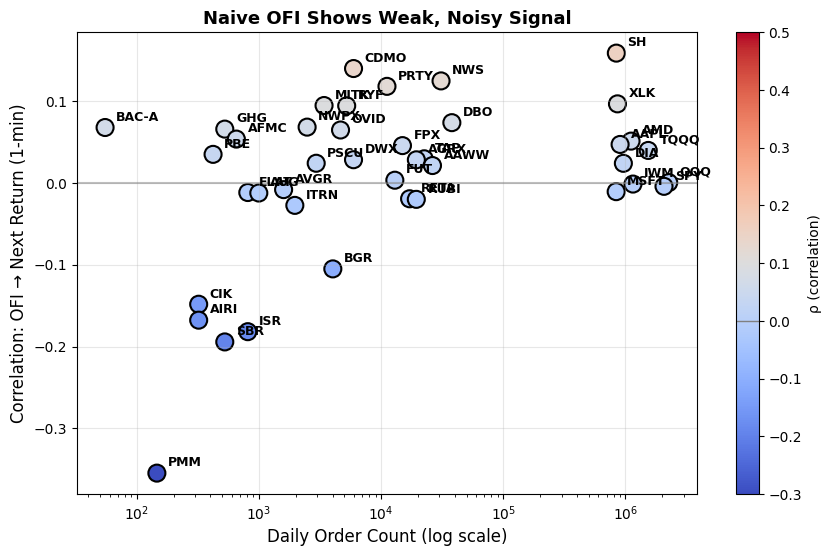

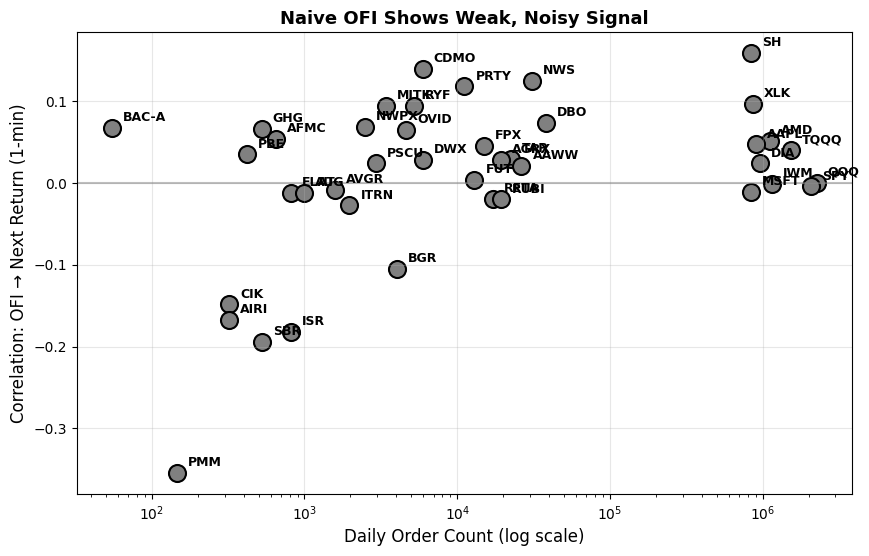

In [33]:
# Filter to symbols with OFI data for Figure 3.3
figure_lob_data = {
    s: lob_data[s] for s in FIGURE_3_3_SYMBOLS if s in lob_data and "ofi" in lob_data[s].columns
}
print(f"\nFigure 3.3: Using {len(figure_lob_data)}/{len(FIGURE_3_3_SYMBOLS)} symbols")

# Run multi-stock OFI analysis on fixed symbol set
multi_stock_results = analyze_all_stocks_ofi(figure_lob_data)

if len(multi_stock_results) >= 3:
    # Persist the 50-stock cross-section so book figure scripts can rebuild
    # Figure 3.3 without re-executing the notebook (Hard Rule 15).
    results_df = pl.DataFrame(
        [
            {
                "symbol": r["symbol"],
                "order_count": r.get("order_count", 0),
                "corr": r["corr"],
                "buckets": r.get("buckets", 0),
            }
            for r in multi_stock_results
        ]
    )
    results_path = OUTPUT_DIR / "figure_3_3_ofi_correlation_50_stocks.parquet"
    results_path.parent.mkdir(parents=True, exist_ok=True)
    results_df.write_parquet(results_path)
    print(f"Persisted Fig 3.3 cross-section: {results_path} ({len(results_df)} symbols)")

    # Generate Figure 3.3 from actual data (color version)
    plot_ofi_vs_returns(multi_stock_results)
    plt.show()

    # Generate grayscale version for print publication
    plot_ofi_vs_returns_grayscale(multi_stock_results)
    plt.show()
else:
    print("\nWARNING: Multi-stock OFI analysis requires multiple stocks for comparison")
    print(
        f"   Only {len(multi_stock_results)} stock(s) available: "
        f"{[r['symbol'] for r in multi_stock_results]}"
    )
    print("   Run notebook 02 with multiple symbols (AAPL, MSFT, UGA, JMST) to see spectrum.")

In [34]:
# Print summary
print("\nFigure 3.3: OFI → Return Correlation Across Stocks")
print("=" * 55)
print(f"{'Symbol':<8} {'Orders':>12} {'Correlation':>12}")
print("-" * 35)
for r in multi_stock_results[:5]:
    oc = r.get("order_count", r.get("buckets", 0))
    print(f"{r['symbol']:<8} {oc:>12,} {r['corr']:>12.3f}")
if len(multi_stock_results) > 8:
    print("...")
    for r in multi_stock_results[-3:]:
        oc = r.get("order_count", r.get("buckets", 0))
        print(f"{r['symbol']:<8} {oc:>12,} {r['corr']:>12.3f}")

if len(multi_stock_results) >= 3:
    corrs = [r["corr"] for r in multi_stock_results]
    print(f"\nCorrelation range: {min(corrs):.2f} to {max(corrs):.2f}")
    print(f"Mean correlation:  {np.mean(corrs):.2f} (weak)")
    print(f"Std deviation:     {np.std(corrs):.2f} (high variance)")
    print("\n→ Naive imbalance is not directly tradeable.")
    print("  Chapter 6 shows how conditional signals extract the edge.")


Figure 3.3: OFI → Return Correlation Across Stocks
Symbol         Orders  Correlation
-----------------------------------
SH            841,722        0.159
CDMO            5,945        0.140
NWS            30,926        0.125
PRTY           11,162        0.118
XLK           859,914        0.097
...
ISR               810       -0.182
SBR               525       -0.194
PMM               146       -0.355

Correlation range: -0.35 to 0.16
Mean correlation:  0.01 (weak)
Std deviation:     0.10 (high variance)

→ Naive imbalance is not directly tradeable.
  Chapter 6 shows how conditional signals extract the edge.


## 6. Summary Statistics

Compute summary metrics for the LOB data we analyzed.

In [35]:
def compute_liquidity_summary(lob_df: pl.DataFrame) -> dict:
    """Compute liquidity summary metrics from LOB data."""
    metrics = {}

    # Spread metrics
    if "spread" in lob_df.columns:
        valid = lob_df.filter(pl.col("spread") > 0)["spread"]
        if len(valid) > 0:
            metrics["mean_spread"] = valid.mean()
            metrics["median_spread"] = valid.median()

    # Price
    if "mid_price" in lob_df.columns:
        metrics["mean_price"] = lob_df["mid_price"].mean()

    # Depth at best level
    if "bid_size_0" in lob_df.columns:
        metrics["mean_bid_depth"] = lob_df["bid_size_0"].mean()
    if "ask_size_0" in lob_df.columns:
        metrics["mean_ask_depth"] = lob_df["ask_size_0"].mean()

    return metrics

In [36]:
# Print summary for available stocks
if lob_data:
    print("\n" + "=" * 60)
    print("LOB Analysis Summary")
    print("=" * 60)

    for symbol, df in lob_data.items():
        metrics = compute_liquidity_summary(df)
        print(f"\n{symbol}:")
        print(f"  Snapshots: {len(df):,}")
        if "mean_price" in metrics:
            print(f"  Avg price: ${metrics['mean_price']:.2f}")
        if "mean_spread" in metrics:
            spread_bps = metrics["mean_spread"] / metrics.get("mean_price", 1) * 10000
            print(f"  Avg spread: ${metrics['mean_spread']:.4f} ({spread_bps:.1f} bps)")
        if "mean_bid_depth" in metrics and "mean_ask_depth" in metrics:
            print(
                f"  Avg depth: {metrics['mean_bid_depth']:,.0f} bid / {metrics['mean_ask_depth']:,.0f} ask"
            )


LOB Analysis Summary

AAPL:
  Snapshots: 22,450
  Avg price: $321.30
  Avg spread: $0.0435 (1.4 bps)
  Avg depth: 158 bid / 177 ask

AAWW:
  Snapshots: 5,325
  Avg price: $23.02
  Avg spread: $0.0440 (19.1 bps)
  Avg depth: 425 bid / 138 ask

AFMC:
  Snapshots: 1,095
  Avg price: $20.24
  Avg spread: $0.0496 (24.5 bps)
  Avg depth: 552 bid / 546 ask

AGRX:
  Snapshots: 5,115
  Avg price: $3.75
  Avg spread: $0.0150 (40.0 bps)
  Avg depth: 2,389 bid / 1,471 ask

AIRI:
  Snapshots: 224
  Avg price: $1.60
  Avg spread: $0.1256 (786.9 bps)
  Avg depth: 133 bid / 134 ask

AMD:
  Snapshots: 22,260
  Avg price: $47.36
  Avg spread: $0.0108 (2.3 bps)
  Avg depth: 1,156 bid / 1,477 ask

AUG:
  Snapshots: 577
  Avg price: $1.30
  Avg spread: $0.0166 (127.6 bps)
  Avg depth: 509 bid / 483 ask

AVGR:
  Snapshots: 1,191
  Avg price: $0.62
  Avg spread: $0.0038 (61.4 bps)
  Avg depth: 1,528 bid / 880 ask

BAC-A:
  Snapshots: 72
  Avg price: $26.54
  Avg spread: $0.5835 (219.8 bps)
  Avg depth: 127 

## Key Takeaways

### Empirical Patterns Demonstrated

| Pattern | Finding | Implication |
|---------|---------|-------------|
| **Spread dynamics** | Intraday U-shape in spreads | Time-of-day conditioning matters |
| **Naive imbalance** | Weak, noisy correlation with returns | Raw features aren't tradeable |
| **Liquidity spectrum** | 100x+ depth variation across stocks | Normalization required |
| **Book reconstruction** | Valid spreads confirm correct parsing | Quality check |

### The Signal Extraction Problem

Figure 3.3 demonstrates a key lesson: **naive order flow metrics don't work**.
Across the 50 NASDAQ stocks, the bucketed OFI→return correlation has a
cross-stock mean of ρ ≈ 0.01 with a standard deviation of ≈ 0.10 and a
range from −0.35 to 0.16 — i.e. centred on noise with high cross-stock
dispersion.

**What's missing?** Chapter 6's order flow reversal strategy shows that tradeable
signals emerge only when you condition on:
- **Extreme events**: One-sided flow above threshold percentiles
- **Spread dynamics**: Transient spread dislocation (expansion ratio)
- **Time-of-day**: Open and close behave differently than midday

### Bridge to Later Chapters

| Chapter | How These Patterns Connect |
|---------|---------------------------|
| **Chapter 6** | Order flow reversal strategy with conditional signals |
| **Chapter 8** | Feature engineering: spread, imbalance, time-of-day |
| **Chapter 9** | Evaluating microstructure signal decay |
| **Chapter 19** | Price impact modeling using liquidity |

---

## Reference

Bouchaud, J.-P., Bonart, J., Donier, J., & Gould, M. (2018).
*Trades, Quotes and Prices: Financial Markets Under the Microscope*.
Cambridge University Press.
[https://doi.org/10.1017/9781009028943](https://doi.org/10.1017/9781009028943)